In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score

from sklearn.linear_model import LogisticRegression

# Oficjalny link
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    # Wczytanie danych do DataFrame
    df = pd.read_csv(url)
    print("Sukces! Dane wczytano pomyślnie.\n")

    # Wyświetlenie podstawowych informacji o zbiorze
    print(df.info())

except Exception as e:
    print(f"Wystąpił błąd podczas pobierania: {e}")

Sukces! Dane wczytano pomyślnie.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

In [ ]:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
mediana = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.drop("customerID", axis=1)

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


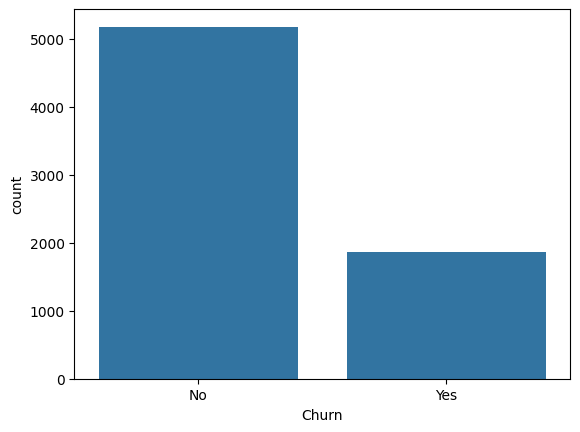

In [ ]:
sns.countplot(x="Churn", data=df)
plt.show()

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}:")
        print(df[col].unique())

gender:
['Female' 'Male']
Partner:
['Yes' 'No']
Dependents:
['No' 'Yes']
PhoneService:
['No' 'Yes']
MultipleLines:
['No phone service' 'No' 'Yes']
InternetService:
['DSL' 'Fiber optic' 'No']
OnlineSecurity:
['No' 'Yes' 'No internet service']
OnlineBackup:
['Yes' 'No' 'No internet service']
DeviceProtection:
['No' 'Yes' 'No internet service']
TechSupport:
['No' 'Yes' 'No internet service']
StreamingTV:
['No' 'Yes' 'No internet service']
StreamingMovies:
['No' 'Yes' 'No internet service']
Contract:
['Month-to-month' 'One year' 'Two year']
PaperlessBilling:
['Yes' 'No']
PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn:
['No' 'Yes']


In [ ]:
binary_map = {'No': 0, 'Yes': 1, 'No internet service': 0}

for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = set(df[col].dropna().unique())

        # check whether the column contains only these values
        if unique_vals.issubset(binary_map.keys()):
            df[col] = df[col].map(binary_map)

In [ ]:
df['MultipleLines'] = df['MultipleLines'].map({'No': 0, 'Yes': 1, 'No phone service': 0})

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}:")
        print(df[col].unique())


gender:
['Female' 'Male']
InternetService:
['DSL' 'Fiber optic' 'No']
Contract:
['Month-to-month' 'One year' 'Two year']
PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:

internet_map = {
        'No': 0,
        'DSL': 1,
        'Fiber optic': 2
    }
df['InternetService'] = df['InternetService'].map(internet_map)

contract_map = {
        'Month-to-month': 0,
        'One year': 1,
        'Two year': 2
    }
df['Contract'] = df['Contract'].map(contract_map)

df



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,1,0,1,0,0,0,0,0,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,1,1,0,1,1,0,0,1,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,1,1,1,0,1,1,1,1,1,1,Mailed check,84.80,1990.50,0
7039,Female,0,1,1,72,1,1,2,0,1,1,0,1,1,1,1,Credit card (automatic),103.20,7362.90,0
7040,Female,0,1,1,11,0,0,1,1,0,0,0,0,0,0,1,Electronic check,29.60,346.45,0
7041,Male,1,1,0,4,1,1,2,0,0,0,0,0,0,0,1,Mailed check,74.40,306.60,1


In [ ]:
# One-Hot Encoding

# select the categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# removing the columns that have already been encoded
categorical_cols = [col for col in categorical_cols if col not in ['InternetService', 'Contract']]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,1,0,1,0,...,0,0,1,29.85,29.85,0,False,False,True,False
1,0,0,0,34,1,0,1,1,0,1,...,0,1,0,56.95,1889.50,0,True,False,False,True
2,0,0,0,2,1,0,1,1,1,0,...,0,0,1,53.85,108.15,1,True,False,False,True
3,0,0,0,45,0,0,1,1,0,1,...,0,1,0,42.30,1840.75,0,True,False,False,False
4,0,0,0,2,1,0,2,0,0,0,...,0,0,1,70.70,151.65,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,1,0,1,...,1,1,1,84.80,1990.50,0,True,False,False,True
7039,0,1,1,72,1,1,2,0,1,1,...,1,1,1,103.20,7362.90,0,False,True,False,False
7040,0,1,1,11,0,0,1,1,0,0,...,0,0,1,29.60,346.45,0,False,False,True,False
7041,1,1,0,4,1,1,2,0,0,0,...,0,0,1,74.40,306.60,1,True,False,False,True


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


models = {
    'Logistic (baseline)':  LogisticRegression(random_state=42),
    'Lasso (L1)':           LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    'Balanced':             LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'Extra Trees':          ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=5174/1869, random_state=42),  # No/Yes
    'LightGBM':             LGBMClassifier(class_weight='balanced', random_state=42),
    'SVM':                  SVC(kernel='rbf', class_weight='balanced', probability=True),
}

all_model_results = []

for name, model in models.items():

    result = cross_validate(
      model, X, y,
      cv=5,
      scoring=['accuracy', 'recall', 'precision', 'f1'],
      return_train_score=True
    )

    # Create a dict for the current model's results


    all_model_results.append({
        'Model': name,
        'Accuracy': result['test_accuracy'].round(4),
        'avg_Accuracy': result['test_accuracy'].mean(),
        'Recall': result['test_recall'].round(4),
        'avg_Recall': result['test_recall'].mean(),
        'Precision': result['test_precision'].round(4),
        'avg_Precision': result['test_precision'].mean(),
        'F1': result['test_f1'].round(4),
        'avg_F1': result['test_f1'].mean(),
    })
df_results = pd.DataFrame(all_model_results).set_index('Model').round(4)
avg_cols = ['avg_Accuracy', 'avg_Recall', 'avg_Precision', 'avg_F1']

df_results.style.highlight_max(subset=avg_cols, axis=0, color='lightgreen')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number

,Accuracy,avg_Accuracy,Recall,avg_Recall,Precision,avg_Precision,F1,avg_F1
Model,,,,,,,,
Logistic (baseline),[0.802 0.8091 0.7906 0.8075 0.8061],0.803100,[0.5374 0.5749 0.5241 0.5684 0.5374],0.548400,[0.6547 0.6615 0.6262 0.6584 0.6678],0.653700,[0.5903 0.6152 0.5706 0.6101 0.5956],0.596300
Lasso (L1),[0.8034 0.8098 0.7913 0.8089 0.8054],0.803800,[0.5535 0.5775 0.5267 0.5657 0.5401],0.552700,[0.653 0.6626 0.6274 0.6635 0.6645],0.654200,[0.5991 0.6171 0.5727 0.6107 0.5959],0.599100
Balanced,[0.7559 0.7587 0.7402 0.7464 0.7507],0.750400,[0.8316 0.8209 0.8102 0.7855 0.762 ],0.802000,[0.5253 0.5293 0.5067 0.514 0.521 ],0.519300,[0.6439 0.6436 0.6235 0.6214 0.6189],0.630300
Random Forest,[0.7842 0.7864 0.7658 0.7969 0.7976],0.786200,[0.4545 0.4626 0.4599 0.4584 0.4973],0.466600,[0.6296 0.6337 0.5733 0.6706 0.6572],0.632900,[0.528 0.5348 0.5104 0.5446 0.5662],0.536800
Gradient Boosting,[0.8119 0.8091 0.7921 0.8075 0.8061],0.805300,[0.5508 0.5428 0.5134 0.5255 0.5241],0.531300,[0.6799 0.6744 0.6337 0.6759 0.6735],0.667500,[0.6086 0.6015 0.5672 0.5913 0.5895],0.591600
Extra Trees,[0.7963 0.7828 0.7601 0.7777 0.7884],0.781100,[0.508 0.4786 0.4332 0.4531 0.4973],0.474000,[0.6485 0.6172 0.5625 0.6079 0.6284],0.612900,[0.5697 0.5392 0.4894 0.5192 0.5552],0.534500
XGBoost,[0.7452 0.7786 0.7502 0.7536 0.7607],0.757600,[0.6738 0.6738 0.6738 0.6542 0.631 ],0.661300,[0.5153 0.5701 0.5228 0.5281 0.5425],0.535800,[0.584 0.6176 0.5888 0.5844 0.5834],0.591700
LightGBM,[0.7537 0.7786 0.7424 0.7479 0.7692],0.758300,[0.7701 0.7594 0.7005 0.7507 0.7139],0.738900,[0.5246 0.5613 0.5107 0.5166 0.5505],0.532700,[0.6241 0.6455 0.5908 0.612 0.6217],0.618800
SVM,[0.6863 0.6572 0.6487 0.6946 0.6719],0.671700,[0.5749 0.5321 0.5508 0.5791 0.5642],0.560200,[0.4317 0.3925 0.3865 0.4417 0.4137],0.413200,[0.4931 0.4518 0.4542 0.5012 0.4774],0.475500


Choosing a metric:
The key metric is Recall—the cost of missing a churning customer (FN) is significantly higher than the cost of a false positive (FP). It is easier for a company to offer a promotion to a loyal customer than to win back a customer who has already left.

In [ ]:
def make_threshold_scorer(metric_func, threshold=0.3, **kwargs):
    def scorer(estimator, X, y):
        y_proba = estimator.predict_proba(X)[:, 1]
        y_pred  = (y_proba >= threshold).astype(int)
        return metric_func(y, y_pred, **kwargs)
    return scorer

threshold = 0.30

scoring_t = {
    'accuracy':  make_threshold_scorer(accuracy_score, threshold=threshold),
    'recall':    make_threshold_scorer(recall_score,    threshold=threshold),
    'precision': make_threshold_scorer(precision_score, threshold=threshold, zero_division=0),
    'f1':        make_threshold_scorer(f1_score,        threshold=threshold),
}

all_model_results = []

for name, model in models.items():

    result = cross_validate(
        model, X, y,
        cv=5,
        scoring=scoring_t,
        return_train_score=False
    )

    all_model_results.append({
        'Model':         name,
        'avg_Accuracy':  result['test_accuracy'].mean(),
        'avg_Recall':    result['test_recall'].mean(),
        'avg_Precision': result['test_precision'].mean(),
        'avg_F1':        result['test_f1'].mean(),
    })

df_results = pd.DataFrame(all_model_results).set_index('Model').round(4)
df_results.style.highlight_max(axis=0, color='lightgreen')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 621
[LightGBM] [Info] Number

,avg_Accuracy,avg_Recall,avg_Precision,avg_F1
Model,,,,
Logistic (baseline),0.763000,0.767200,0.537600,0.632100
Lasso (L1),0.764400,0.769400,0.539500,0.634100
Balanced,0.650100,0.926200,0.426700,0.584200
Random Forest,0.754100,0.719100,0.527000,0.608200
Gradient Boosting,0.761500,0.752300,0.536600,0.626000
Extra Trees,0.738900,0.685900,0.505900,0.582300
XGBoost,0.715200,0.786000,0.478000,0.594300
LightGBM,0.697300,0.859800,0.462400,0.601200
SVM,0.676300,0.549500,0.417200,0.474200


In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=10000)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.3).astype(int)


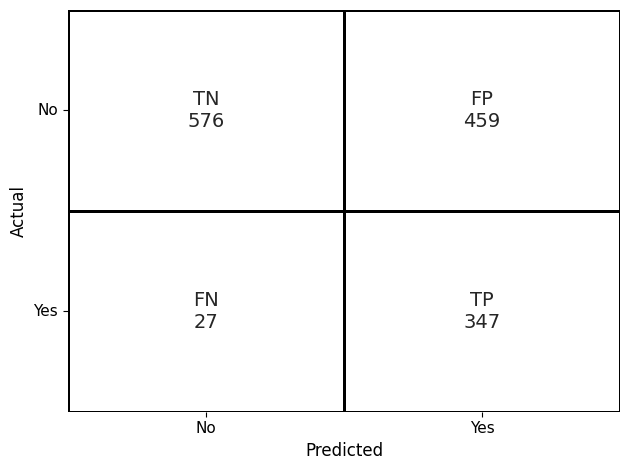

In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = [['TN', 'FP'],
          ['FN', 'TP']]

annot = [[f"{labels[i][j]}\n{cm[i][j]}" for j in range(2)] for i in range(2)]

sns.heatmap(
    cm,
    annot=annot,
    fmt='',
    cmap=['white'],
    linewidths=2,
    linecolor='black',
    cbar=False,
    annot_kws={'size': 14}
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks([0.5, 1.5], ['No', 'Yes'], fontsize=11)
plt.yticks([0.5, 1.5], ['No', 'Yes'], fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

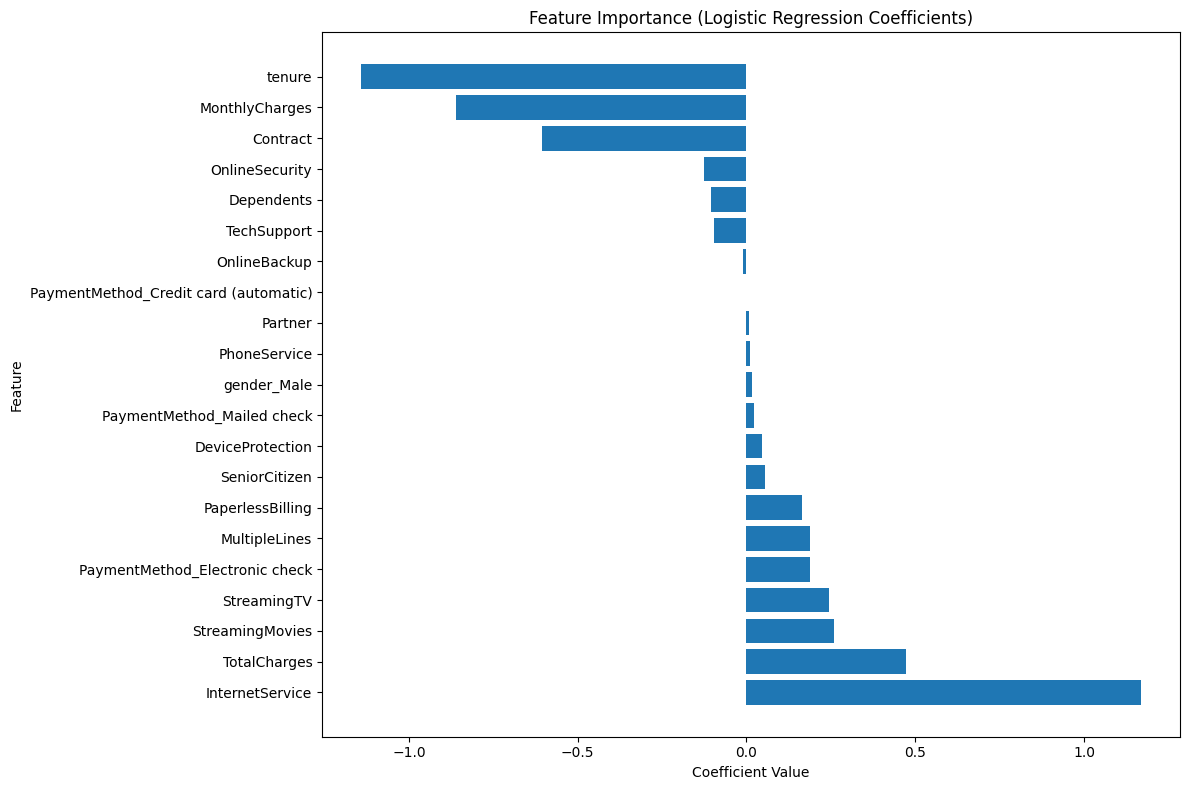

In [ ]:
feature_importance = model.coef_[0]
feature_names = X.columns

# Create a pandas Series for easier manipulation and sorting
feat_series = pd.Series(feature_importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feat_series.index, feat_series.values)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

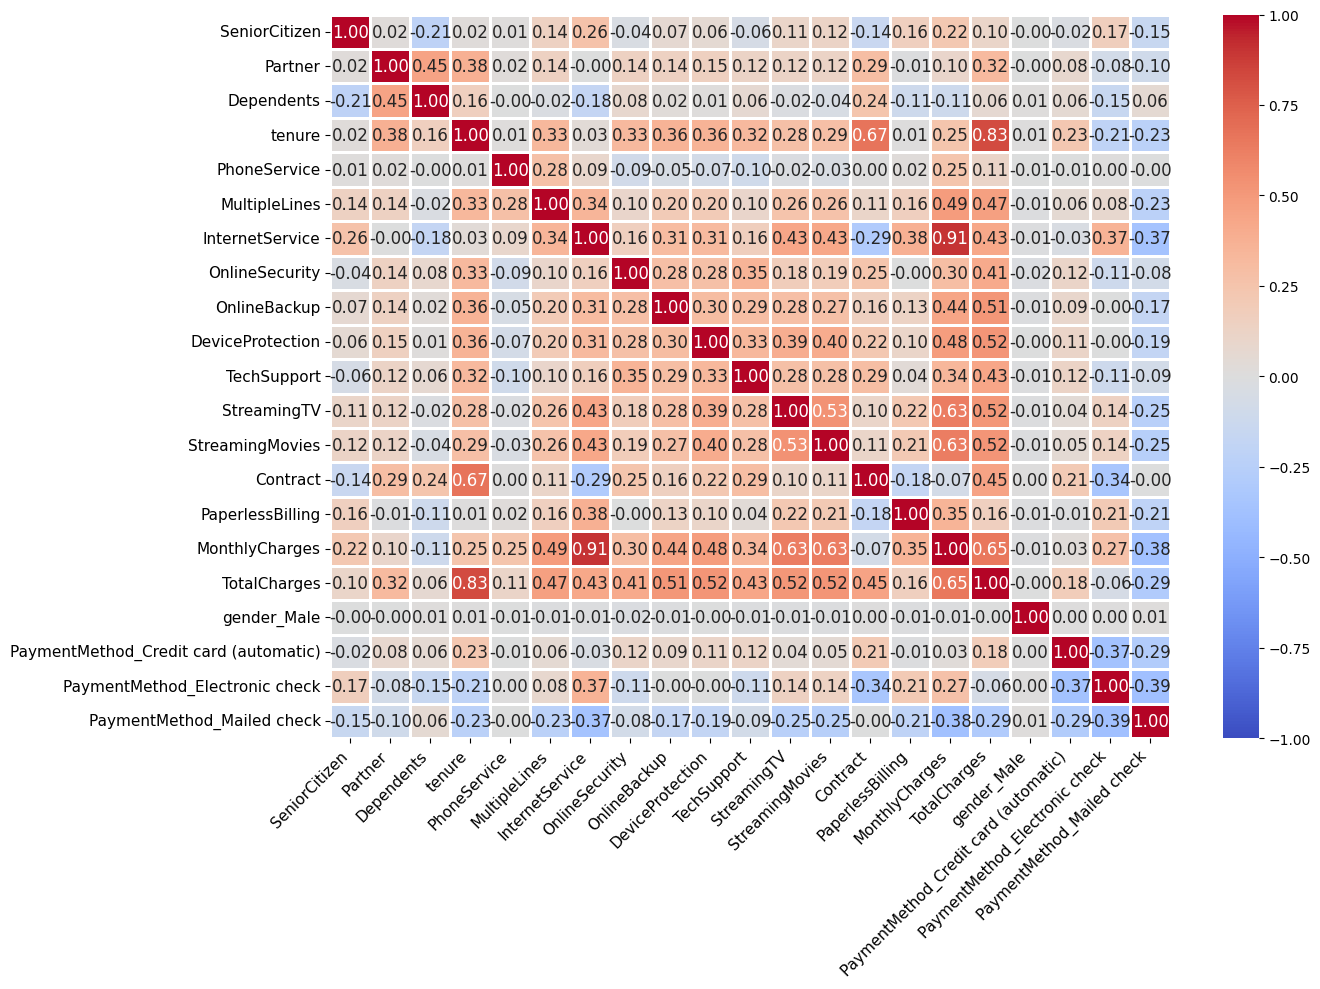

In [ ]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 12},
    vmin=-1, vmax=1,
    ax=ax
)

plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

It simplifies the model by removing two columns (InternetService, TotalCharges) due to the strong correlation between InternetService and MonthlyCharges (0.91) and between TotalCharges and tenure (0.83)

In [ ]:
new_df= df.copy()

In [ ]:
new_df = new_df.drop(["InternetService", "TotalCharges"], axis=1, errors='ignore')
new_df

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,gender_Male,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,0,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,0,True,False,False,True
2,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,1,True,False,False,True
3,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,0,True,False,False,False
4,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,1,1,1,0,1,1,1,1,1,1,84.80,0,True,False,False,True
7039,0,1,1,72,1,1,0,1,1,0,1,1,1,1,103.20,0,False,True,False,False
7040,0,1,1,11,0,0,1,0,0,0,0,0,0,1,29.60,0,False,False,True,False
7041,1,1,0,4,1,1,0,0,0,0,0,0,0,1,74.40,1,True,False,False,True


In [ ]:
X2 = new_df.drop("Churn", axis=1)
y2 = new_df["Churn"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

In [ ]:
models = {
    'Logistic (baseline)': LogisticRegression(max_iter=1000, random_state=42),
    'Lasso (L1)': LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    'Balanced': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(class_weight='balanced', random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees':          ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'XGBoost':              XGBClassifier(scale_pos_weight=5174/1869, random_state=42),  # No/Yes
    'LightGBM':             LGBMClassifier(class_weight='balanced', random_state=42),
    'SVM':                  SVC(kernel='rbf', class_weight='balanced', probability=True),
}

all_model_results2 = []

for name, model in models.items():

    result = cross_validate(
      model, X2, y2,
      cv=5,
      scoring=['accuracy', 'recall', 'precision', 'f1'],
      return_train_score=True
    )

    # Create a dict for the current model's results


    all_model_results2.append({
        'Model': name,
        'Accuracy': result['test_accuracy'].round(4),
        'avg_Accuracy': result['test_accuracy'].mean(),
        'Recall': result['test_recall'].round(4),
        'avg_Recall': result['test_recall'].mean(),
        'Precision': result['test_precision'].round(4),
        'avg_Precision': result['test_precision'].mean(),
        'F1': result['test_f1'].round(4),
        'avg_F1': result['test_f1'].mean(),
    })
df_results2 = pd.DataFrame(all_model_results2).set_index('Model').round(4)
avg_cols = ['avg_Accuracy', 'avg_Recall', 'avg_Precision', 'avg_F1']

df_results2.style.highlight_max(subset=avg_cols, axis=0, color='lightgreen')



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 363
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

,Accuracy,avg_Accuracy,Recall,avg_Recall,Precision,avg_Precision,F1,avg_F1
Model,,,,,,,,
Logistic (baseline),[0.8041 0.8105 0.7842 0.8026 0.8018],0.800700,[0.5561 0.5749 0.5 0.5496 0.5294],0.542000,[0.6541 0.6656 0.6151 0.6508 0.6578],0.648700,[0.6012 0.6169 0.5516 0.5959 0.5867],0.590500
Lasso (L1),[0.8034 0.8119 0.785 0.8018 0.8011],0.800700,[0.5561 0.5802 0.5 0.5469 0.5294],0.542500,[0.652 0.6677 0.6172 0.6497 0.6556],0.648400,[0.6003 0.6209 0.5524 0.5939 0.5858],0.590700
Balanced,[0.7502 0.7587 0.7374 0.7493 0.7493],0.749000,[0.8262 0.8128 0.7968 0.7802 0.7567],0.794500,[0.5185 0.5296 0.5034 0.5178 0.5193],0.517700,[0.6371 0.6414 0.617 0.6225 0.6159],0.626800
Random Forest,[0.7942 0.7885 0.7715 0.7905 0.8004],0.789000,[0.4759 0.4652 0.4465 0.4531 0.5 ],0.468200,[0.6544 0.6397 0.5922 0.65 0.6655],0.640400,[0.5511 0.5387 0.5091 0.534 0.571 ],0.540800
Gradient Boosting,[0.8098 0.8034 0.7864 0.8104 0.7997],0.801900,[0.5374 0.5321 0.4947 0.5174 0.5053],0.517400,[0.6791 0.6611 0.6229 0.6893 0.6608],0.662600,[0.6 0.5896 0.5514 0.5911 0.5727],0.581000
Extra Trees,[0.7828 0.7686 0.7573 0.7699 0.7876],0.773300,[0.4599 0.4679 0.4278 0.4424 0.4947],0.458500,[0.6232 0.5795 0.5556 0.5872 0.6271],0.594500,[0.5292 0.5178 0.4834 0.5046 0.5531],0.517600
XGBoost,[0.7459 0.7715 0.7402 0.7528 0.772 ],0.756500,[0.6604 0.6765 0.639 0.6488 0.6417],0.653300,[0.5167 0.5573 0.5085 0.5272 0.5621],0.534400,[0.5798 0.6111 0.5664 0.5817 0.5993],0.587700
LightGBM,[0.7431 0.7679 0.7445 0.7486 0.7656],0.753900,[0.762 0.7406 0.7246 0.7534 0.7353],0.743200,[0.5108 0.5464 0.5133 0.5175 0.5435],0.526300,[0.6116 0.6288 0.6009 0.6135 0.625 ],0.616000
SVM,[0.7048 0.7367 0.7182 0.7152 0.7188],0.718700,[0.8075 0.7995 0.7781 0.748 0.7807],0.782800,[0.4675 0.5025 0.481 0.4761 0.4818],0.481800,[0.5922 0.6171 0.5945 0.5819 0.5959],0.596300


The analysis reveals that simplifying the model led to a marginal decrease in the most important evaluation metrics. Although both recall and accuracy were slightly lower compared to the full model, the differences were minimal and may be considered acceptable given the gains in model interpretability and reduced complexity.

In [ ]:
def optimize_threshold(model, X_test, y_test, max_fp_ratio=0.2, step=0.01):
    """
    Szuka progu maksymalizującego Recall
    przy założeniu że FP/(TP+FP+TN+FN) <= max_fp_ratio

    Parametry:
        model       : wytrenowany model z predict_proba
        X_test      : dane testowe
        y_test      : etykiety testowe
        max_fp_ratio: maksymalny dopuszczalny stosunek FP do wszystkich próbek
        step        : krok przeszukiwania progów
    """

    y_proba = model.predict_proba(X_test)[:, 1]
    total   = len(y_test)

    best_threshold = 0.5
    best_recall    = 0.0
    results        = []

    for threshold in np.arange(0.01, 1.0, step):
        y_pred = (y_proba >= threshold).astype(int)

        cm = confusion_matrix(y_test, y_pred)
        TN, FP, FN, TP = cm.ravel()

        fp_ratio = FP / total
        recall   = recall_score(y_test, y_pred, zero_division=0)

        results.append({
            'Threshold': round(threshold, 2),
            'Recall':    round(recall, 4),
            'FP_ratio':  round(fp_ratio, 4),
            'TP': TP, 'FP': FP,
            'TN': TN, 'FN': FN,
            'Constraint_OK': fp_ratio <= max_fp_ratio
        })

        # Aktualizuj najlepszy próg jeśli spełnia warunek
        if fp_ratio <= max_fp_ratio and recall > best_recall:
            best_recall    = recall
            best_threshold = round(threshold, 2)

    # Wyniki jako DataFrame
    df_results = pd.DataFrame(results)

    print(f"Najlepszy próg:  {best_threshold}")
    print(f"Najlepszy Recall: {best_recall:.4f}")
    print(f"Maks. FP ratio:  {max_fp_ratio}")

    return best_threshold, best_recall, df_results


# Użycie
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train, y_train)

best_threshold, best_recall, df_results = optimize_threshold(
    model      = model_balanced,
    X_test     = X_test,
    y_test     = y_test,
    max_fp_ratio = 0.2,
    step         = 0.01
)

Najlepszy próg:  0.51
Najlepszy Recall: 0.8204
Maks. FP ratio:  0.2


Business Recommendations:

- Target retention efforts at customers with month-to-month and fiber optic contracts—the highest churn risk
- Implement a model with a threshold of 0.3–0.5 to maximize detection rates
- Proactively offer longer-term contracts to customers with a high likelihood of churn before they decide to leave
- Monitor customers with short tenure—new customers are most at risk of churning

In [ ]:
# Re-initialize and fit the model (the 'Balanced' one, as used previously)
model = LogisticRegression(class_weight='balanced', max_iter=100)
model.fit(X_train, y_train)

# Scale the full dataset X using the previously fitted scaler
X_full_scaled = scaler.transform(X)

#Dodaje infromacje od predyckji i przewidywanym churn do tabeli, te informacje przydadzą sie do wizualizacji
df2['Predicted_Churn'] = model.predict(X_full_scaled)
df2['Probability'] = model.predict_proba(X_full_scaled)[:, 1]
df2.to_csv('predicted_churn.csv', index=False)
df2

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- InternetService
- TotalCharges


# **Pierwsze pytania biznesowe:**  
**GŁÓWNE**: Czy dany klient zrezygnuje z usułgi w najblizszym czasie, to w najbliższym to jest kwesti czy jest powyżej 0,5 czy nie tak

**teraz pytania biznesowe pod to pytanie:**
- co chcemy osiągnąć?
- co chcmey zrozumieć jakie dycyzje ma ma ten raport pomóc podjąć?